In [90]:
#IMPORTS LIBRARY

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D,
    Dense, Flatten, Reshape
)
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [91]:
#MODEL MAKING LDWT Layer(Lifting Wavelet Transform )+ILDWT Layer(Inverse Lifting Wavelet Transform) + Sparsity Layer+ KLD Loss(Kullback Leibler divergence)+AHT(Adaptive Hard Thresholding)

class LDWTLayerTF(tf.keras.layers.Layer):

    def call(self, x):

        x = tf.cast(x, tf.float32)

        batch = tf.shape(x)[0]
        length = tf.shape(x)[1]
        channels = tf.shape(x)[2]

        # split
        x_even = x[:, ::2, :]
        x_odd  = x[:, 1::2, :]

        # symmetric padding
        x_even_l = tf.pad(x_even, [[0,0],[1,0],[0,0]], mode="SYMMETRIC")
        x_even_r = tf.pad(x_even, [[0,0],[0,1],[0,0]], mode="SYMMETRIC")

        # predict
        v = x_odd - 0.5 * (x_even_l[:, :-1, :] + x_even_r[:, 1:, :])

        # pad v
        v_l = tf.pad(v, [[0,0],[1,0],[0,0]], mode="SYMMETRIC")
        v_r = tf.pad(v, [[0,0],[0,1],[0,0]], mode="SYMMETRIC")

        # update
        u = x_even + 0.25 * (v_l[:, :-1, :] + v_r[:, 1:, :])

        # interleave
        uv = tf.stack([u, v], axis=2)

        out = tf.reshape(uv, [batch, length, channels])

        return out

    def compute_output_shape(self, input_shape):
        return input_shape


class AHT(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
    
    def build(self,input_shape):
        #self.Ci=self.add_weight(shape=(input_shape[-1],),initializer="ones",trainable=True,name="C")
        self.Ci = self.add_weight(
    shape=(input_shape[-1],),
    initializer=tf.keras.initializers.Constant(0.1),
    trainable=True,
    name="C"
)

        self.Bi=self.add_weight(shape=(input_shape[-1],),initializer="ones",trainable=True,name="beta")

    def call(self,x):
        C=tf.reshape(self.Ci,(1,1,-1))
        beta=tf.reshape(self.Bi,(1,1,-1))

        E_t=tf.sign(x)*tf.nn.relu(tf.abs(x)-C)
        x_cap=(E_t+C*tf.sign(E_t))*beta

        return x_cap
     
class sparsity_loss_layer(tf.keras.layers.Layer):
    def __init__(self,lam=0.1):
        super().__init__()
        self.lam = lam

    def call(self,x):
        x1 = tf.cast(x, tf.float32)
        z_bar=tf.reduce_mean(tf.abs(x1),axis=[0,1])
        z_cap=tf.nn.softmax(z_bar,axis=0)

        # prevent log(0)
        eps = 1e-7
        z_cap = tf.clip_by_value(z_cap, eps, 1 - eps)

        lam=self.lam
        kld=lam*tf.math.log(lam/z_cap)+(1-lam)*tf.math.log((1-lam)/(1-z_cap))
        sparsity_loss=tf.reduce_sum(kld)
        self.add_loss(0.009*sparsity_loss)

        return x

def build_encoder(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(32, kernel_size=3, activation='tanh', padding='same')(inp)
    x = LDWTLayerTF()(x)


    b1 = Conv1D(64, 3, padding='same')(x)
    b1 = AHT()(b1)
    b1 = Conv1D(64, 3, padding='same')(b1)
    b1 = AHT()(b1)
    b1 = Conv1D(64, 3, padding='same')(b1)
    b1 = AHT()(b1)

    b2 = Conv1D(64, 1, padding='same')(x)
    b2 = AHT()(b2)

    x = tf.keras.layers.Add()([b1, b2])
        
    x = sparsity_loss_layer()(x)

    return Model(inp, x, name="Encoder")


class ILDWTLayerTF(tf.keras.layers.Layer):

    def call(self, x):

        x = tf.cast(x, tf.float32)

        batch   = tf.shape(x)[0]
        length  = tf.shape(x)[1]
        channels= tf.shape(x)[2]

        u = x[:, ::2, :]
        v = x[:, 1::2, :]

        v_l = tf.pad(v, [[0,0],[1,0],[0,0]], mode="SYMMETRIC")
        v_r = tf.pad(v, [[0,0],[0,1],[0,0]], mode="SYMMETRIC")

        x_even = u - 0.25 * (v_l[:, :-1, :] + v_r[:, 1:, :])

        x_even_l = tf.pad(x_even, [[0,0],[1,0],[0,0]], mode="SYMMETRIC")
        x_even_r = tf.pad(x_even, [[0,0],[0,1],[0,0]], mode="SYMMETRIC")

        x_odd = v + 0.5 * (x_even_l[:, :-1, :] + x_even_r[:, 1:, :])

        xo = tf.stack([x_even, x_odd], axis=2)

        out = tf.reshape(xo, [batch, length, channels])

        return out

    def compute_output_shape(self, input_shape):
        return input_shape

def build_decoder(input_shape):
    inp = Input(shape=input_shape)
    x = ILDWTLayerTF()(inp)


    x1 = Conv1D(64, kernel_size=1, activation='tanh', padding='same')(x)
    x1 = tf.keras.layers.Add()([x1, x])

    x2 = Conv1D(64, kernel_size=1, activation='tanh', padding='same')(x1)
    x2 = tf.keras.layers.Add()([x2, x1])

    out = Conv1D(1, kernel_size=1, activation='linear', padding='same')(x2)

    return Model(inp,out,name="Decoder")





In [92]:
#DATA SET COLLECTION XJTU Bearing dataset with 35Hz RPM,12KN Load on shaft.

csv_files = glob.glob(r'F:\Data compression\dataset\XJTU-SY_Bearing_Datasets\35Hz12kN\Bearing1_1\*.csv')
dfs=[]
k=0
for file in csv_files:
    df=(pd.read_csv(file)).to_numpy()
    df=df[:,0].reshape(-1,1)
    dfs.append(df)

    if(k>20):
        break
    k+=1

dataset=[]
for f in dfs:
    l=f.tolist()
    dataset.extend(l)

dataset = np.array(dataset, dtype=np.float32)

mean = np.mean(dataset)
std = np.std(dataset)
dataset_norm = (dataset - mean) / (std+1e-8)

window_size=64
stride=32
final_dataset=[]
for i in range(0,len(dataset)-window_size+1,stride):
    window=dataset[i:i+window_size]
    final_dataset.append(window)


final_dataset = np.array(final_dataset, dtype=np.float32)
final_dataset = final_dataset[..., np.newaxis]

In [93]:
#ACTUAL MODEL Encoder Decoder and complete model.

encoder = build_encoder(input_shape=(64, 1))
decoder = build_decoder(input_shape=(64, 64))
inp = tf.keras.Input(shape=(64, 1))
z = encoder(inp) 
out = decoder(z)
model = tf.keras.Model(inp, out, name="LWT_AHT_Model")


Epoch 1/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - loss: 1.3904
Epoch 2/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - loss: 0.2156
Epoch 3/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - loss: 0.1366
Epoch 4/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step - loss: 0.1017
Epoch 5/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - loss: 0.0860
Epoch 6/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - loss: 0.0780
Epoch 7/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 42s 9ms/step - loss: 0.0733
Epoch 8/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - loss: 0.0703
Epoch 9/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - loss: 0.0683
Epoch 10/10
4506/4506 ━━━━━━━━━━━━━━━━━━━━ 51s 11ms/step - loss: 0.0671


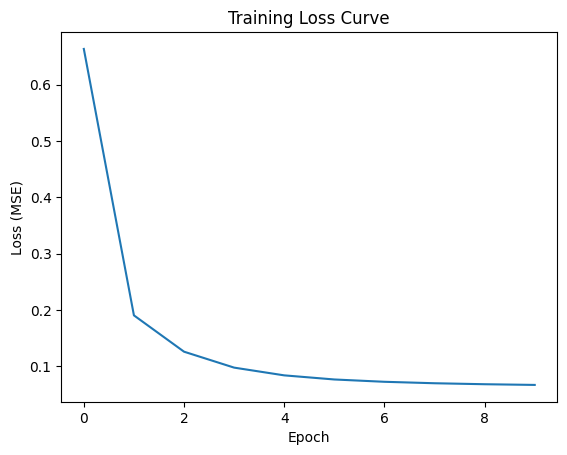

In [94]:
#TRAINING using Adam as optimizer,Two losses are there one is reconstruction loss and other is sparsity loss.

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=tf.keras.losses.MeanSquaredError())
history=model.fit(
    final_dataset,        
    final_dataset,       
    batch_size=5,        
    epochs=10,
    shuffle=True
)

plt.plot(history.history['loss'])
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.show()


704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
(22527, 64, 1)
(22527, 64, 1, 1)
MSE is 0.005393557


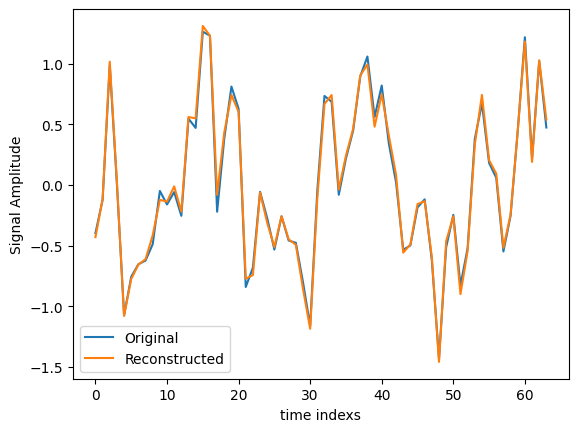

In [95]:
#After training Plotting reconstuction Vs Original on a single window on Trained Data.
reconstructed = model.predict(final_dataset)
print(reconstructed.shape)
print(final_dataset.shape)

mse = np.mean((final_dataset.reshape(-1,64,1) - reconstructed)**2)
print("MSE is",mse)

orig=final_dataset[0,:,0]
rec=reconstructed[0,:,0]
plt.plot(orig, label="Original")
plt.plot(rec, label="Reconstructed")
plt.xlabel("time indexs")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.show()

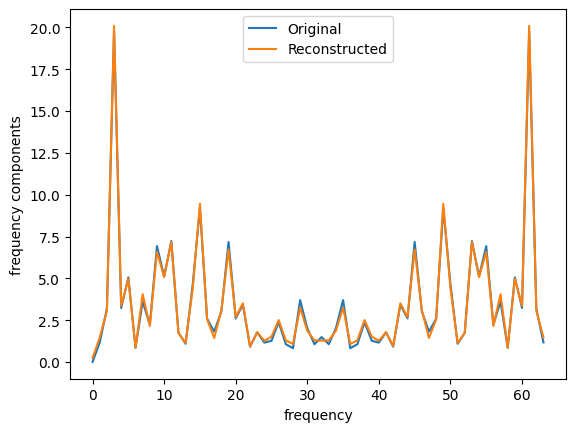

In [96]:
#On trained Data Plotting FFT of Reconstruction Vs Original.

orig_fft = np.abs(np.fft.fft(orig.flatten()))
rec_fft  = np.abs(np.fft.fft(rec.flatten()))

plt.plot(orig_fft, label="Original")
plt.plot(rec_fft, label="Reconstructed")
plt.xlabel("frequency")
plt.ylabel("frequency components")
plt.legend()
plt.show()

In [97]:
#Testing Part Choosing 5 signals for testing.

dfs=[]
k=0
for file in csv_files:
    if(k<22):
        k+=1
        continue
    else:
        df=(pd.read_csv(file)).to_numpy()
        df=df[:,0].reshape(-1,1)
        dfs.append(df)
    if(k>27):
        break
    k+=1

dataset=[]
for f in dfs:
    l=f.tolist()
    dataset.extend(l)

dataset = np.array(dataset, dtype=np.float32)

dataset_norm = (dataset - mean) / (std+1e-8)

window_size=64
stride=32
final_dataset=[]
for i in range(0,len(dataset)-window_size+1,stride):
    window=dataset[i:i+window_size]
    final_dataset.append(window)


final_dataset = np.array(final_dataset, dtype=np.float32)
final_dataset = final_dataset[..., np.newaxis]



224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
MSE is 0.1555181


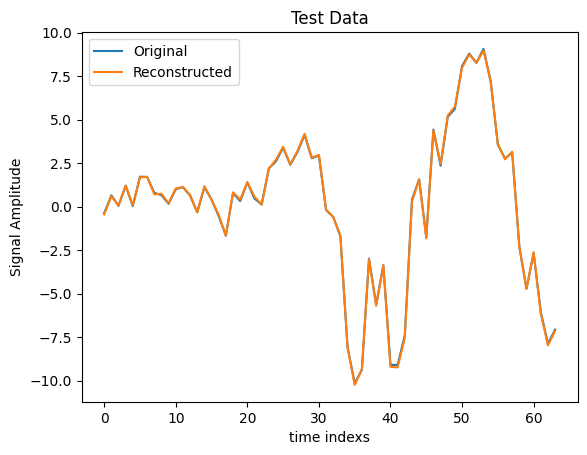

In [102]:
# Plotting reconstuction Vs Original Signal on a single window on Testing Data.
reconstructed = model.predict(final_dataset)
mse = np.mean((final_dataset.reshape(-1,64,1) - reconstructed)**2)
print("MSE is",mse)

orig=final_dataset[0,:,0]
rec=reconstructed[0,:,0]

plt.plot(orig, label="Original")
plt.plot(rec, label="Reconstructed")
plt.xlabel("time indexs")
plt.ylabel("Signal Amplitude")
plt.title("Test Data")
plt.legend()
plt.show()

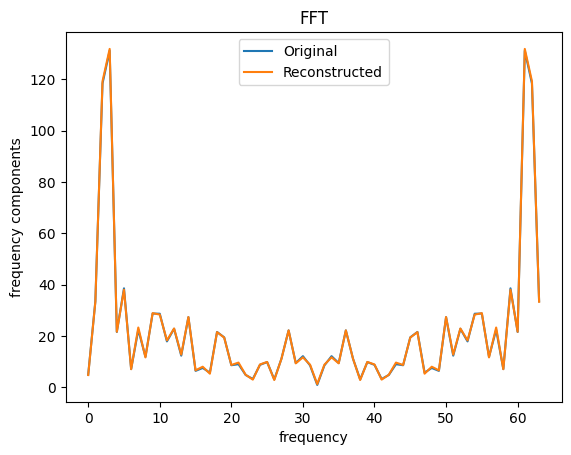

In [103]:
# Plotting reconstuction Vs Original FFT on a single window on Testing Data.
orig_fft = np.abs(np.fft.fft(orig.flatten()))
rec_fft  = np.abs(np.fft.fft(rec.flatten()))

plt.plot(orig_fft, label="Original")
plt.plot(rec_fft, label="Reconstructed")
plt.xlabel("frequency")
plt.ylabel("frequency components")
plt.title("FFT")
plt.legend()
plt.show()

In [100]:
#Calculating metrics for PRD,SNR,Sparsity for Testing Signal

orig = final_dataset.flatten()
rec  = reconstructed.flatten()

prd = np.sqrt(np.sum((orig - rec)**2) / np.sum(orig**2)) * 100
snr = 10*np.log10(np.sum(orig**2) / np.sum((orig-rec)**2))
encoded_test = encoder.predict(final_dataset)
z = encoded_test.flatten()

threshold = 1e-3
nonzero = np.sum(np.abs(z) > threshold)

sparsity = 1 - nonzero/len(z)

print("Test Sparsity:", sparsity)

print("Test PRD :",prd)
print("Test SNR :",snr)

224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Test Sparsity: 0.3518021441044893
Test PRD : 9.674759
Test SNR : 20.287197
